# Preprocessing

In [37]:
import nltk
from nltk.corpus import reuters, stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import seaborn as sns
import html

In [38]:
dataset_1 = pd.read_csv('../data/FinalBalancedDataset.csv')
dataset_2 = pd.read_csv('../data/TweetDataset.csv')

dataset_1 = dataset_1.rename(columns={'Toxicity': 'label'})

dataset_1 = dataset_1[['label', 'tweet']]
dataset_2 = dataset_2[['label', 'tweet']]

df = pd.concat([dataset_1, dataset_2], ignore_index=True)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


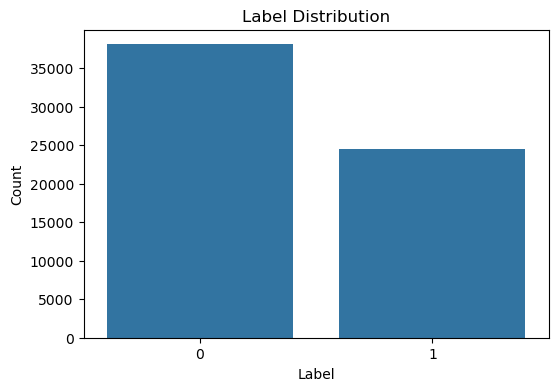

In [39]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [40]:
# Lowercase
df['tweet'] = df['tweet'].str.lower()
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [41]:
# Check if they have URL or HTML tags
have_url = df["tweet"].str.contains('http\S+|www\S+', regex=True).any()
have_html = df["tweet"].str.contains('<.*?>', regex=True).any()

print("Rows contain URL:", have_url)
print("Rows contain HTML:", have_html)

Rows contain URL: True
Rows contain HTML: False


In [42]:
# Remove URL
def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

df['tweet'] = df['tweet'].apply(remove_url)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [43]:
# Remove HTML entities like & (&amp;), < (&lt;), " (&quot;)
df['tweet'] = df['tweet'].apply(lambda x: html.unescape(x) if isinstance(x, str) else x)
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [44]:
# Remove @user before the @ is removed from removing the punctuation
def remove_mentions(text):
    return re.sub(r'@\w+', '', text)

df['tweet'] = df['tweet'].apply(remove_mentions)
df.head()

,label,tweet
0,0,when a father is dysfunctional and is so sel...
1,0,thanks for #lyft credit i can't use cause th...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [45]:
# Remove symbols and numbers
def remove_symbols(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # text = re.sub(r'\s+', ' ', text).strip()
    return text

df['tweet'] = df['tweet'].apply(remove_symbols)
df.head()

,label,tweet
0,0,when a father is dysfunctional and is so sel...
1,0,thanks for lyft credit i cant use cause they...
2,0,bihday your majesty
3,0,model i love u take with u all the time in u...
4,0,factsguide society now motivation


In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
custom_words = ['im', 'u', 'ur', 'amp', 'user', 'get', 'got', 'rt']
stop_words.update(custom_words)

# Remove stopwords
def remove_stopwords(text):
    # Split text, keep word ONLY if it is not in stopwords
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

df['tweet'] = df['tweet'].apply(remove_stopwords)
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fjoshlyn/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,tweet
0,0,father dysfunctional selfish drags kids dysfun...
1,0,thanks lyft credit use cause offer wheelchair ...
2,0,bihday majesty
3,0,model love take time
4,0,factsguide society motivation


In [47]:
# from sklearn.utils import resample
# max_size = df['label'].value_counts().max()
# lst = [df[df['label'] == i] for i in df['label'].unique()]

# df_balanced = pd.DataFrame()
# for sub_df in lst:
#     df_resampled = resample(sub_df, replace=True, n_samples=max_size, random_state=42)
#     df_balanced = pd.concat([df_balanced, df_resampled])

# print("Distribution after balancing:")
# print(df_balanced['label'].value_counts())

In [48]:
from sklearn.utils import resample
import pandas as pd

# 1. Find the size of the largest class
max_size = df['label'].value_counts().max()

# 2. Create an empty list to hold our resampled dataframes
resampled_dfs = []

# 3. Loop through each unique label (dropping NaNs to prevent ValueError)
for label in df['label'].dropna().unique(): 
    sub_df = df[df['label'] == label]
    
    # Upsample the minority classes to match max_size
    df_resampled = resample(sub_df, replace=True, n_samples=max_size, random_state=42)
    resampled_dfs.append(df_resampled)

# 4. Concatenate everything ONCE at the end and reset the index
df_balanced = pd.concat(resampled_dfs, ignore_index=True)

print("Distribution after balancing:")
print(df_balanced['label'].value_counts())

Distribution after balancing:
label
0    38074
1    38074
Name: count, dtype: int64


In [49]:
# Tokenization
from nltk.tokenize import word_tokenize,sent_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

df_balanced['tweet'] = df_balanced['tweet'].apply(word_tokenize)
df_balanced.head()

[nltk_data] Downloading package punkt to /Users/fjoshlyn/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/fjoshlyn/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,label,tweet
0,0,"[people, like, nothing, contribute, kick, cont..."
1,0,"[friday, xoxosamantha, via]"
2,0,"[thank, much, following, please, read, flighto..."
3,0,"[whos, watch, wwdc, live, stream, apple, event..."
4,0,"[walked, fo, amherst, babe, look, cutie, mine,..."


In [50]:
# Lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(word_list):
    # If the word is 'ass', leave it alone. Otherwise, lemmatize normally.
    return [word if word == 'ass' else lemmatizer.lemmatize(word) for word in word_list]

df_balanced['tweet'] = df_balanced['tweet'].apply(lemmatize_text)
df_balanced.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/fjoshlyn/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/fjoshlyn/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,label,tweet
0,0,"[people, like, nothing, contribute, kick, cont..."
1,0,"[friday, xoxosamantha, via]"
2,0,"[thank, much, following, please, read, flighto..."
3,0,"[who, watch, wwdc, live, stream, apple, event,..."
4,0,"[walked, fo, amherst, babe, look, cutie, mine,..."


In [51]:
# Final Check of Top 20 Most Common Words
all_words = [word for sublist in df_balanced['tweet'] for word in sublist]

word_counts = Counter(all_words)
most_common_words = word_counts.most_common(20)

print('\nMost common words:')
for word, count in most_common_words:
    print(f'{word}: {count}')


Most common words:
bitch: 17699
hoe: 6626
like: 5554
love: 4402
day: 3981
pussy: 3445
nigga: 3174
ass: 2543
fuck: 2399
happy: 2350
time: 2255
shit: 2165
one: 2049
life: 1996
go: 1936
aint: 1920
lol: 1881
good: 1871
make: 1867
girl: 1864


# Visualization

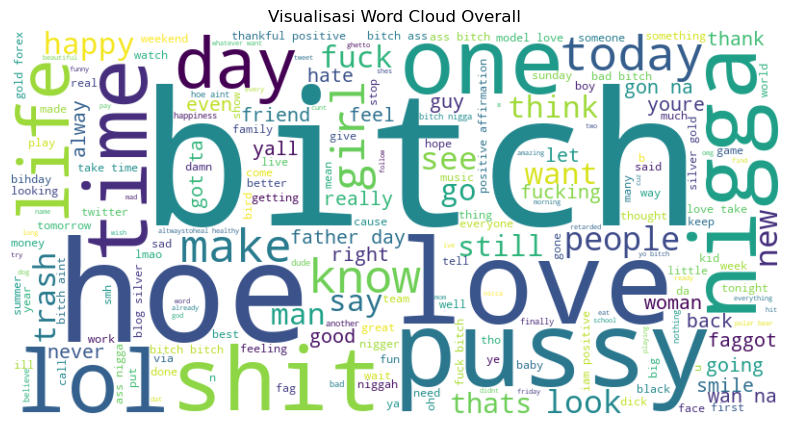

In [52]:
# Word Cloud
def plot_wordcloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Visualisasi Word Cloud Overall")
    plt.show()

all_words = []

for tokens in df_balanced['tweet']:
    all_words.extend(tokens)

plot_wordcloud(" ".join(all_words))

In [53]:
df_balanced.to_csv('../data/preprocessed_result_260304_01.csv', index=False, encoding='utf-8')